<a href="https://colab.research.google.com/github/ryankrismer/EM_field_solver/blob/main/EM_field_solver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Electromagnetic field solver

In [2]:
import numpy as np
import tqdm
import sys
import matplotlib.pyplot as plt

# Set threshold to infinity or system maximum
np.set_printoptions(threshold=sys.maxsize)

## General functions

In [3]:
def find_dist(r, r_ref):
  """
  Function to calculate the spatial distance between 2 coordinates

  Parameters:
    r:      [x, y, z] (m) (1D numpy array)
    r_ref:  [x_ref, y_ref, z_ref] (m) (1D numpy array of floats)

  Returns: Distance between coordinates (float)
  """
  return np.sqrt((r[0] - r_ref[0]) ** 2 + (r[1] - r_ref[1]) ** 2 + (r[2] - r_ref[2]) ** 2)

In [4]:
def find_r(x, y, z):
  """
  Function to find spherical radial coordinate value, given a particular cartesian position

  Parameters:
    x: x coordinate value (m) (float)
    y: y coordinate value (m) (float)
    z: z coordinate value (m) (float)

  Returns: Value of spherical radial coordinate (m) (float)
  """
  return find_dist([x, y, z], [0.0, 0.0, 0.0])

In [5]:
def find_theta(z, r):
  """
  Function to find spherical polar coordinate value, given a particular cartesian position

  Parameters:
    z: z coordinate value (m) (float)
    r: Spherical radial coordinate value (m) (float)

  Returns: Value of spherical polar coordinate (rad) (float)
  """
  return np.arccos(z / r)

In [6]:
def find_Delta_r(x, y, z):
  """
  Function to find value of spherical radial coordinate differential for particular cartesian position

  Parameters:
    x: x coordinate value (m) (float)
    y: y coordinate value (m) (float)
    z: z coordinate value (m) (float)

  Returns: Value of spherical radial coordinate differential (m) (float)

  Note: Assumes a cartesian differential corresponding to source lattice
  """
  return Delta_L_src * np.abs(x + y + z) / find_r(x, y, z)

In [ ]:
def find_phi(x, y):
  """
  Function to find value of spherical polar coordinate

  Parameters:
    x:  Value of x coordinate (m) (float)
    y:  Value of y coordinate (m) (float)

  Returns: Value of spherical polar coordinate (rad) (float)
  """
  return np.arctan2(y, x)

In [ ]:
def find_lambda(phi, t):
  """
  Function to find value of lambda coordinate

  Parameters:
    phi:  Value of spherical azimuthal coordinate (rad) (float)
    t:    Value of time coordinate (s) (float)

  Returns: Value of lambda coordinate (rad) (float)
  """
  return phi - omega * t

## Setting sources and lattices

In [194]:
# Defining constants and parameters

# E&M constants
c = 299792458                         # Speed of light in vacuum (m * s^-1)
epsilon_0 = 8.8541878188 * 10 ** -12  # Vacuum electric permissivity (F * m^-1)
mu_0 = 1.25663706127 * 10 ** -6       # Vacuum magnetic permeability (N * A^-2)

###############################################################################

# Pulsar parameters
R = 10.0 * 10 ** 3    # Radius (m)
omega = 2 * np.pi     # Rotational speed (rad * s^-1)
P = 2 * np.pi / omega # Rotational period of pulsar (s)
chi = np.pi / 4       # Angle between magnetic dipole axis and rotational axis z (rad)
cos_chi = np.cos(chi) # Cosine of angle between magnetic dipole axis and rotational axis z (rad)
sin_chi = np.sin(chi) # Sine of angle between magnetic dipole axis and rotational axis z (rad)
R1 = 10 ** 8 / mu_0   # Arbitrary function of spherical radial coordinate; same order of magnitude as surface H field (A * m^-1)
R3 = 10 ** 8 / mu_0   # Arbitrary function of spherical radial coordinate; same order of magnitude as surface H field (A * m^-1)
alpha = omega / c * R # Dimensionless radius of pulsar (dimensionless)

################################################################################################################################

# Source lattice parameters
L_src_out = R                                     # Outer boundary of source lattice (m)
n_src_max = int(16)                               # Size of each source spatial coordinate axis
print(f"n_src_max is {n_src_max}")
Delta_L_src = (L_src_out + L_src_out) / n_src_max # Actual distance between adjacent source spatial coordinate values (m)
print(f"Delta_L_src is {Delta_L_src}")

# Ensuring L_in is an integer number of grid spacings
L_in_goal = R / np.sqrt(3.0)
L_in = int(L_in_goal / Delta_L_src) * Delta_L_src # Inner boundary of source lattice (m)
print(f"L_in is {L_in}, {L_in / Delta_L_src} * Delta_L_src")

#########################################################################################################################

# Setting source spatial lattice points
P_src_tbxy = np.arange(-L_src_out, L_src_out + Delta_L_src, Delta_L_src)  # x and y coordinate values for source top and bottom lattices (m)

P_src_tz_1x_2y = np.arange(L_in, L_src_out + Delta_L_src, Delta_L_src)    # z coordinate values for source top lattice,
                                                                          # x coordinate values for source lattice 1,
                                                                          # y coordinate values for source lattice 2 (m)

P_src_bz_3x_4y = np.arange(-L_src_out, -L_in + Delta_L_src, Delta_L_src)  # z coordinate values for source bottom lattice,
                                                                          # x coordinate values for source lattice 3,
                                                                          # y coordinate values for source lattice 4 (m)

P_src_sz = np.arange(-L_in, L_in, Delta_L_src)                            # z coordinate values for source side lattices (m)

P_src_2x_3y = np.arange(-L_src_out, L_in, Delta_L_src)                    # x coordinate values for source lattice 2,
                                                                          # y coordinate values for source lattice 3 (m)

P_src_4x_1y = np.arange(-L_in, L_src_out + Delta_L_src, Delta_L_src)      # x coordinate values for source lattice 4,
                                                                          # y coordinate values for source lattice 1 (m)

############################################################################################################################################

# Observation lattice parameters
L_obs_out = 10 * R                        # Outer boundary of observation lattice (m)
N_obs = int(17)                           # Size of each observation spatial coordinate axis
print(f"N_obs is {N_obs}")
Delta_L_obs = (L_obs_out - L_in) / N_obs  # Distance between adjacent observation spatial coordinate values (m)

###############################################################################################################

# General lattice parameters pt 2
Delta_t = Delta_L_src / c # Difference between consecutive time coordinate values (s)
N_t = int(30)             # Size of time coordinate axis
print(f"N_t is {N_t}")

#####################################################################################

# Time lattice points
T = np.linspace(0.0, Delta_t * (N_t - 1), N_t)  # Time axis (s)

n_src_max is 16
Delta_L_src is 1250.0
L_in is 5000.0, 4.0 * Delta_L_src
N_obs is 17
N_t is 30


### Functions

In [8]:
def find_src_params(t,
                    x,
                    y,
                    z,
                    r,
                    omega,
                    cos_chi,
                    sin_chi,
                    R3,
                    R1 = None
                   ):
  """
  Function to find values of source coordinates and functions from particular cartesian position

  Parameters:
    t:        Time coordinate value (s) (float)
    x:        x coordinate value (m) (float)
    y:        y coordinate value (m) (float)
    z:        z coordinate value (m) (float)
    r:        Spherical radial coordinate value (m) (float)
    omega:    Rotational speed of pulsar (rad * s^-1) (float)
    cos_chi:  Cosine of angle between pulsar's magnetic dipole axis and rotational axis z (dimensionless) (float)
    sin_chi:  Sine of angle between pulsar's magnetic dipole axis and rotational axis z (dimensionless) (float)
    R3:       Arbitrary function of spherical radial coordinate; same order of magnitude as surface H field (A * m^-1) (float)
    R1:       Arbitrary function of spherical radial coordinate; same order of magnitude as surface H field (A * m^-1) (float)

  Returns:
    cos_phi:    Cosine of spherical azimuthal coordinate (rad) (float)
    sin_phi:    Sine of spherical azimuthal coordinate (rad) (float)
    cos_lambda: Cosine of lambda coordinate (dimensionless) (float)
    theta:      Value of spherical polar coordinate (rad) (float)
    cos_theta:  Cosine of spherical polar coordinate (dimensionless) (float)
    sin_theta:  Sine of spherical polar coordinate (dimensionless) (float)
    R2:         Value of arbitrary function R2, given R1 (A * m^-1) (float)
    C:          Value of C function (dimensionless) (float)
    D:          Value of D function (A * m^-1) (float)
    F:          Value of F function (dimensionless) (float)
    G:          Value of G function (A * m^-1) (float)

  Note: the current form assumes R1 is constant
  """
  phi = find_phi(x, y)
  cos_phi = np.cos(phi)
  sin_phi = np.sin(phi)

  lambda_coord = find_lambda(phi, t)
  cos_lambda = np.cos(lambda_coord)

  theta = find_theta(z, r)
  cos_theta = np.cos(theta)
  sin_theta = np.sin(theta)

  C = cos_chi * sin_theta - sin_chi * cos_theta * cos_lambda

  psi = np.arccos(cos_chi * cos_theta + sin_chi * sin_theta * cos_lambda)
  S3 = np.cos(psi)
  D = R3 * S3 / np.sin(psi)

  F = sin_chi * np.sin(lambda_coord)

  # Only calculating R2 and G if necessary
  if R1 is None:
    R2 = None
    G = None
  else:
    R2 = -R1  # Will need to be modified if R1 isn't constant
    G = R2 - 1 / 2 * R1

  return cos_phi, sin_phi, cos_lambda, theta, cos_theta, sin_theta, R2, C, D, F, G

In [9]:
def src(t,
        x,
        y,
        z,
        omega = 2 * np.pi,
        R1 = 10 ** 8 / mu_0,
        R3 = 10 ** 8 / mu_0,
        cos_chi = np.sqrt(2.0) / 2,
        sin_chi = np.sqrt(2.0) / 2
       ):
  """
  Function to find charge and current distributions for vacuum retarded dipole model of a pulsar

  Parameters:
    t:        Time coordinate value (s) (float)
    x:        x coordinate value (m) (float)
    y:        y coordinate value (m) (float)
    z:        z coordinate value (m) (float)
    omega:    Rotational speed of pulsar (rad * s^-1) (float)
    R1:       Arbitrary function of spherical radial coordinate; same order of magnitude as surface H field (A * m^-1) (float)
    R3:       Arbitrary function of spherical radial coordinate; same order of magnitude as surface H field (A * m^-1) (float)
    cos_chi:  Cosine of angle between pulsar's magnetic dipole axis and rotational axis z (rad) (float)
    sin_chi:  Sine of angle between pulsar's magnetic dipole axis and rotational axis z (rad) (float)

  Returns:  Surface charge density and surface current density at source position (t, x, y, z)
            (form [sigma, K_x, K_y, K_z]) (sigma is C * m^-2, K_i is A * m^-1) (each is float)
  """
  r = find_r(x, y, z)

  cos_phi, sin_phi, cos_lambda, theta, cos_theta, sin_theta, R2, C, D, F, G = find_src_params(t,
                                                                                              x,
                                                                                              y,
                                                                                              z,
                                                                                              r,
                                                                                              omega,
                                                                                              cos_chi,
                                                                                              sin_chi,
                                                                                              R3,
                                                                                              R1
                                                                                             )

  # Sigma
  sigma_term_1a = cos_chi * (3 * np.cos(2 * theta) + 1)
  sigma_term_1b = 3 * sin_chi * np.sin(2 * theta) * cos_lambda

  sigma_term_1 = 1 / 4 * R1 * (sigma_term_1a + sigma_term_1b)
  sigma_term_2 = (R2 * C - D * F) * sin_theta

  sigma = -omega * R / c ** 2 * (sigma_term_1 + sigma_term_2)

  # K_theta and K_phi
  K_theta = G * F + D * C
  K_phi = -G * C + D * F

  # K_x
  K_x_term_1 = K_theta * cos_theta * cos_phi
  K_x_term_2 = -K_phi * sin_phi

  K_x = K_x_term_1 + K_x_term_2

  # K_y
  K_y_term_1 = K_theta * cos_theta * sin_phi
  K_y_term_2 = K_phi * cos_phi

  K_y = K_y_term_1 + K_y_term_2

  # K_z
  K_z = -K_theta * sin_theta

  return [sigma, K_x, K_y, K_z]

### Creating source lattice positions and sources

In [10]:
# # Creating sources
# n_src_tbxy = np.size(P_src_tbxy)
# n_src_tz_1x_2y = np.size(P_src_tz_1x_2y)
# n_src_bz_3x_4y = np.size(P_src_bz_3x_4y)
# n_src_4x_1y = np.size(P_src_4x_1y)
# n_src_sz = np.size(P_src_sz)
# n_src_2x_3y = np.size(P_src_2x_3y)

# sigma_t = np.full((N_t, n_src_tbxy, n_src_tbxy, n_src_tz_1x_2y), np.nan)
# K_x_t = sigma_t
# K_y_t = sigma_t
# K_z_t = sigma_t

# sigma_b = np.full((N_t, n_src_tbxy, n_src_tbxy, n_src_bz_3x_4y), np.nan)
# K_x_b = sigma_b
# K_y_b = sigma_b
# K_z_b = sigma_b

# sigma_1 = np.full((N_t, n_src_tz_1x_2y, n_src_4x_1y, n_src_sz), np.nan)
# K_x_1 = sigma_1
# K_y_1 = sigma_1
# K_z_1 = sigma_1

# sigma_2 = np.full((N_t, n_src_2x_3y, n_src_tz_1x_2y, n_src_sz), np.nan)
# K_x_2 = sigma_2
# K_y_2 = sigma_2
# K_z_2 = sigma_2

# sigma_3 = np.full((N_t, n_src_bz_3x_4y, n_src_2x_3y, n_src_sz), np.nan)
# K_x_3 = sigma_3
# K_y_3 = sigma_3
# K_z_3 = sigma_3

# sigma_4 = np.full((N_t, n_src_4x_1y, n_src_bz_3x_4y, n_src_sz), np.nan)
# K_x_4 = sigma_4
# K_y_4 = sigma_4
# K_z_4 = sigma_4

# # Packing lattice stuff up
# n_src_x_arr = [n_src_tbxy, n_src_tbxy, n_src_tz_1x_2y, n_src_2x_3y, n_src_bz_3x_4y, n_src_4x_1y]
# P_src_x_arr = [P_src_tbxy, P_src_tbxy, P_src_tz_1x_2y, P_src_2x_3y, P_src_bz_3x_4y, P_src_4x_1y]

# n_src_y_arr = [n_src_tbxy, n_src_tbxy, n_src_4x_1y, n_src_tz_1x_2y, n_src_2x_3y, n_src_bz_3x_4y]
# P_src_y_arr = [P_src_tbxy, P_src_tbxy, P_src_4x_1y, P_src_tz_1x_2y, P_src_2x_3y, P_src_bz_3x_4y]

# n_src_z_arr = [n_src_tz_1x_2y, n_src_bz_3x_4y, n_src_sz, n_src_sz, n_src_sz, n_src_sz]
# P_src_z_arr = [P_src_tz_1x_2y, P_src_bz_3x_4y, P_src_sz, P_src_sz, P_src_sz, P_src_sz]

# sigma_arr = [sigma_t, sigma_b, sigma_1, sigma_2, sigma_3, sigma_4]
# K_x_arr = [K_x_t, K_x_b, K_x_1, K_x_2, K_x_3, K_x_4]
# K_y_arr = [K_y_t, K_y_b, K_y_1, K_y_2, K_y_3, K_y_4]
# K_z_arr = [K_z_t, K_z_b, K_z_1, K_z_2, K_z_3, K_z_4]
# label_arr = ["t", "b", "1", "2", "3", "4"]

In [11]:
# # Setting each source point
# for l in range(6):

#   # Unpacking lattice stuff
#   label = label_arr[l]
#   n_src_x = n_src_x_arr[l]
#   n_src_y = n_src_y_arr[l]
#   n_src_z = n_src_z_arr[l]

#   P_src_x = P_src_x_arr[l]
#   P_src_y = P_src_y_arr[l]
#   P_src_z = P_src_z_arr[l]

#   sigma = sigma_arr[l]
#   K_x = K_x_arr[l]
#   K_y = K_y_arr[l]
#   K_z = K_z_arr[l]

#   for t in tqdm.tqdm(range(N_t)):
#     for x in range(n_src_x):
#       for y in range(n_src_y):
#         for z in range(n_src_z):
#           t_i = T[t]
#           x_i = P_src_x[x]
#           y_i = P_src_y[y]
#           z_i = P_src_z[z]
#           r = find_r(x_i, y_i, z_i)

#           # Finding the maximum uncertainty in r
#           r_errs = []

#           for i in range(2):
#             for j in range(2):
#               for k in range(2):
#                 x_corner = x_i + (-1) ** i * Delta_L_src / 2
#                 y_corner = y_i + (-1) ** j * Delta_L_src / 2
#                 z_corner = z_i + (-1) ** k * Delta_L_src / 2
#                 r_errs.append(np.abs(r - find_r(x_corner, y_corner, z_corner)))

#           r_err = np.max(r_errs)

#           if np.abs(r - R) <= r_err:  # Dirac delta function condition
#             src_i = find_Delta_r(x_i, y_i, z_i) * np.array(src(t_i, x_i, y_i, z_i, omega, R1, R3, cos_chi, sin_chi))
#             sigma[t, x, y, z] = src_i[0]
#             K_x[t, x, y, z] = src_i[1]
#             K_y[t, x, y, z] = src_i[2]
#             K_z[t, x, y, z] = src_i[3]
#           else:
#             continue

#   np.save(f"sigma_{label}.npy", sigma)
#   np.save(f"K_x_{label}.npy", K_x)
#   np.save(f"K_y_{label}.npy", K_y)
#   np.save(f"K_z_{label}.npy", K_z)

## Finding potentials from sources

### Functions

In [12]:
def causally_related(dist_src, t_i_src, t_i_obs):
  """
  Function to evaluate whether source point is causally related to observation point

  Parameters:
    dist_src: Distance between source and observation points (m) (float)
    t_i_src:  Value of time for source point (s) (float)
    t_i_obs:  Value of time for observation point (s) (float)
    L_err:    Uncertainty due to discreteness of spatial lattice (m) (float)

  Returns: True if source point is causally related to observation point, False otherwise (boolean)
  """
  t_r_err = (Delta_t + np.sqrt(3) / c * (Delta_L_src + Delta_L_obs)) / 2

  return np.abs(t_i_obs - dist_src / c - t_i_src) <= t_r_err

In [13]:
def Delta_theta(x, y, z, r):
  """
  Function to find value of spherical polar coordinate differential for particular cartesian position

  Parameters:
    x: x coordinate value (m) (float)
    y: y coordinate value (m) (float)
    z: z coordinate value (m) (float)
    r: spherical radial coordinate value (m) (float)

  Returns: Value of spherical polar coordinate differential (rad) (float)

  Note: Assumes a cartesian differential corresponding to source lattice
  """
  return Delta_L_src / np.sqrt(x ** 2 + y ** 2) * np.abs(z * (x + y + z) / r ** 2 - 1)

In [14]:
def Delta_phi(x, y):
  """
  Function to find value of spherical azimuthal coordinate differential for particular cartesian position

  Parameters:
    x: x coordinate value (m) (float)
    y: y coordinate value (m) (float)

  Returns: Value of spherical polar coordinate differential (rad) (float)

  Note: Assumes a cartesian differential corresponding to source lattice
  """
  return Delta_L_src * np.abs(x - y) / (x ** 2 + y ** 2)

In [15]:
def Delta_A(x, y, z):
  """
  Function to find value of spherical surface area differential for particular cartesian position

  Parameters:
    x: x coordinate value (m) (float)
    y: y coordinate value (m) (float)
    z: z coordinate value (m) (float)

  Returns: Value of spherical surface area differential (m^2) (float)

  Note: Assumes a cartesian differential corresponding to source lattice
  """
  r = find_r(x, y, z)
  return Delta_theta(x, y, z, r) * Delta_phi(x, y) * r ** 2 * np.sin(find_theta(z, r))

In [16]:
def find_src_sum(src_arr, Delta_f):
  """
  Function to find source sums for potential functions

  Parameters:
    src_arr:  Source distribution from each lattice (format: [src_t, src_b, src_1, src_2, src_3, src_4]) (each is 4D numpy array of floats)
    Delta_f:  Differential function to evaluate: Delta_A() for scalar potential and Delta_r for vector potential (function)

  Returns: Sums of source contributions for each observation point (4D numpy array of floats)

  Note: For all 4D arrays involved, axes are ordered as [t, x, y, z]
  """
  src_sum = np.full((N_t, N_obs, N_obs, N_obs), np.nan) # Creating 4D array w/ set number of values per observation coordinate

  # Calculating and setting values for each plottable observation point
  for t_obs in tqdm.tqdm(range(N_t)):
    t_i_obs = T[t_obs]

    for x_obs in tqdm.tqdm(range(N_obs)):
      x_i_obs = P_obs[x_obs]

      for y_obs in range(N_obs):
        y_i_obs = P_obs[y_obs]
        r_x_y = find_r(x_i_obs, y_i_obs, 0.0) # Distance of (x, y) from origin (m)

        if r_x_y > L_obs_out: # True if (x, y) line is beyond plotting region
          if y_i_obs > 0.0:   # True if all future y values will also be beyond plotting region
            break

          continue  # Skip this y value but continue iterating through y

        for z_obs in range(N_obs):
          valid_obs_point = False               # Default to not summing up source contributions
          z_i_obs = P_obs[z_obs]
          r = find_r(x_i_obs, y_i_obs, z_i_obs) # Distance from origin (m)

          if r <= R:  # Ensuring we only save values we're going to plot
            continue

          src_term = []

          # Iterating through all source points that occur at an earlier time than observation time
          for l in range(6):
            # Unpacking lattice stuff
            n_src_x = n_src_x_arr[l]
            n_src_y = n_src_y_arr[l]
            n_src_z = n_src_z_arr[l]

            P_src_x = P_src_x_arr[l]
            P_src_y = P_src_y_arr[l]
            P_src_z = P_src_z_arr[l]

            src = src_arr[l]

            for t_src in range(t_obs + 1):
              t_i_src = T[t_src]

              for x_src in range(n_src_x):
                x_i_src = P_src_x[x_src]

                for y_src in range(n_src_y):
                  y_i_src = P_src_y[y_src]

                  for z_src in range(n_src_z):
                    if np.isnan(src[t_src, x_src, y_src, z_src]): # Ensuring we don't check empty points
                      continue

                    z_i_src = P_src_z[z_src]
                    dist_src = find_dist([x_i_obs, y_i_obs, z_i_obs], [x_i_src, y_i_src, z_i_src])  # Distance from src (m)

                    # Only contributions are source points causally related to observation points
                    if causally_related(dist_src, t_i_src, t_i_obs):
                      valid_obs_point = True
                      src_term.append(Delta_f(x_i_src, y_i_src, z_i_src) * src[t_src, x_src, y_src, z_src] / dist_src)

          if valid_obs_point:
            src_sum[t_obs, x_obs, y_obs, z_obs] = np.sum(src_term) # Adding up all the source contributions

  return src_sum

In [17]:
def find_Phi(sigma_arr):
  """
  Function to find scalar potential from charge distribution

  Parameter:
    sigma_arr:  charge distribution (collection of surface density segments from each source lattice)
                (format: [sigma_t, sigma_b, sigma_1, sigma_2, sigma_3, sigma_4]) (C * m^-2) (each is 4D numpy array of floats)

  Returns: scalar potential (V) (4D numpy array of floats)

  Note: For all 4D arrays involved, axes are ordered as [t, x, y, z]
  """
  return Delta_t / (4 * np.pi * epsilon_0) * find_src_sum(sigma_arr, Delta_A)

In [18]:
def find_A_i(K_i_arr):
  """
  Function to find component of vector potential from current distribution

  Parameter:
    K_i_arr:  i component of current distribution (collection of surface density segments from each source lattice)
              (format: [K_i_t, K_i_b, K_i_1, K_i_2, K_i_3, K_i_4]) (A * m^-1) (each is 4D numpy array of floats)

  Returns: i component of vector potential (T * m) (4D numpy array of floats)

  Note: For all 4D arrays involved, axes are ordered as [t, x, y, z]
  """
  return mu_0 * Delta_t * Delta_L_src / (4 * np.pi) * find_src_sum(K_i_arr, find_Delta_r)

### Finding potentials

In [19]:
# Setting observation lattice points
P_obs = np.linspace(-L_obs_out, L_obs_out, N_obs) # Positional coordinate values for each observation spatial axis (m)

In [20]:
# # Finding scalar potential
# sigma_arr = []

# for l in range(6):
#   sigma_arr.append(np.load(f"sigma_{label_arr[l]}.npy"))

# Phi = find_Phi(sigma_arr)
# np.save(f"Phi.npy", Phi)

In [21]:
# # Finding vector potential A_x
# K_x_arr = []

# for l in range(6):
#   K_x_arr.append(np.load(f"K_x_{label_arr[l]}.npy"))

# A_x = find_A_i(K_x_arr)
# np.save(f"A_x.npy", A_x)

In [22]:
# # Finding vector potential A_y
# K_y_arr = []

# for l in range(6):
#   K_y_arr.append(np.load(f"K_y_{label_arr[l]}.npy"))

# A_y = find_A_i(K_y_arr)
# np.save(f"A_y.npy", A_y)

In [23]:
# # Finding vector potential A_z
# K_z_arr = []

# for l in range(6):
#   K_z_arr.append(np.load(f"K_z_{label_arr[l]}.npy"))

# A_z = find_A_i(K_z_arr)
# np.save(f"A_z.npy", A_z)

## Finding fields from potentials

### Functions

In [24]:
def find_E_i(Phi, A, i):
  """
  Function to find E field component from potentials Phi and A_i

  Parameters:
    Phi:  scalar potential (V) (4D numpy array of floats)
    A:    [A_x, A_y, A_z] components of vector potential (T * m) (each is 4D numpy array of floats)
    i:    field component desired

  Returns: i component of E field (N * C^-1) (4D numpy array of floats)

  Note: For all 4D arrays involved, axes are ordered as [t, x, y, z]
  """
  if i != 1 and i != 2 and i != 3:
    raise ValueError("i value not allowed. i must be a spatial index within [1, 2, 3]")

  # Finding A component based on index value
  A_i = A[i - 1]

  return -np.gradient(Phi, axis = i) - np.gradient(A_i, axis = 0)

In [25]:
def find_B_i(A, i):
  """
  Function to find B field component from potential A

  Parameters:
    A: [A_x, A_y, A_z] components of vector potential (T * m) (each is 4D numpy array of floats)
    i: field component desired

  Returns: i component of B field (T) (4D numpy array of floats)

  Note: For all 4D arrays involved, axes are ordered as [t, x, y, z]
  """
  # Finding index values to ensure cyclicity
  if i == 1:
    j = 2
    k = 3
  elif i == 2:
    j = 3
    k = 1
  elif i == 3:
    j = 1
    k = 2
  else:
    raise ValueError("i value not allowed. i must be a spatial index within [1, 2, 3]")

  # Finding A components based on index values
  A_j = A[j - 1]
  A_k = A[k - 1]

  return np.gradient(A_k, axis = j) - np.gradient(A_j, axis = k)

### Finding fields

In [26]:
# # Finding E_x
# Phi = np.load("Phi.npy")
# A_x = np.load("A_x.npy")
# A_y = np.load("A_y.npy")
# A_z = np.load("A_z.npy")

# E_x = find_E_i(Phi, [A_x, A_y, A_z], 1)
# np.save(f"E_x.npy", E_x)

In [27]:
# # Finding E_y
# Phi = np.load("Phi.npy")
# A_x = np.load("A_x.npy")
# A_y = np.load("A_y.npy")
# A_z = np.load("A_z.npy")

# E_y = find_E_i(Phi, [A_x, A_y, A_z], 2)
# np.save(f"E_y.npy", E_y)

In [28]:
# # Finding E_z
# Phi = np.load("Phi.npy")
# A_x = np.load("A_x.npy")
# A_y = np.load("A_y.npy")
# A_z = np.load("A_z.npy")

# E_z = find_E_i(Phi, [A_x, A_y, A_z], 3)
# np.save(f"E_z.npy", E_z)

In [29]:
# # Finding B_x
# A_x = np.load("A_x.npy")
# A_y = np.load("A_y.npy")
# A_z = np.load("A_z.npy")

# B_x = find_B_i([A_x, A_y, A_z], 1)
# np.save(f"B_x.npy", B_x)

In [30]:
# # Finding B_y
# A_x = np.load("A_x.npy")
# A_y = np.load("A_y.npy")
# A_z = np.load("A_z.npy")

# B_y = find_B_i([A_x, A_y, A_z], 2)
# np.save(f"B_y.npy", B_y)

In [31]:
# # Finding B_z
# A_x = np.load("A_x.npy")
# A_y = np.load("A_y.npy")
# A_z = np.load("A_z.npy")

# B_z = find_B_i([A_x, A_y, A_z], 3)
# np.save(f"B_z.npy", B_z)

## Plotting fields

### Functions

In [155]:
def slice_field(F, coord, id_1, id_2, id_3):
  """
  Function to slice field component F along specified coordinate axis

  Parameters:
    F:      Field component to slice (4D numpy array of floats) (axes are ordered [t, x, y, z])
    coord:  Coordinate to slice along, of ["t", "x", "y", "z,"] (string)
    id_1:   Index of coordinate 1 to use for slice (int)
    id_2:   Index of coordinate 2 to use for slice (int)
    id_3:   Index of coordinate 3 to use for slice (int)

  Returns: Field component F sliced along axis corresponding to coordinate coord (1D numpy array of floats)

  Note: coordinate to slice along will be labeled "coord", and other coordinates will be labeled "1, 2, 3"
  """
  if coord == "t":
    F_slice = F[:, id_1, id_2, id_3]
  elif coord == "x":
    F_slice = F[id_1, :, id_2, id_3]
  elif coord == "y":
    F_slice = F[id_1, id_2, :, id_3]
  else:
    F_slice = F[id_1, id_2, id_3, :]

  return F_slice

In [287]:
def mask_interior_fields(F_unmasked):
  """
  Function to mask interior fields

  Parameter:
    F_unmasked: Unmasked field component (4D numpy array of floats)

  Returns: masked field (4D numpy array of floats)

  Note: For all 4D arrays involved, axes are ordered as [t, x, y, z]
  """
  F_masked = F_unmasked

  for x_obs in range(N_obs):
    x_i_obs = P_obs[x_obs]

    for y_obs in range(N_obs):
      y_i_obs = P_obs[y_obs]

      for z_obs in range(N_obs):
        z_i_obs = P_obs[z_obs]
        r = find_r(x_i_obs, y_i_obs, z_i_obs) # Distance from origin (m)

        if r <= R:  # Ensuring we only save values we're going to plot
          F_masked[:, x_obs, y_obs, z_obs] = np.full((N_t), np.nan)

  return F_masked

In [ ]:
def find_rho(r):
  """
  Function to find value of rho coordinate

  Parameter:
    r: Value of spherical radial coordinate (m) (float)

  Returns: Value of rho coordinate (dimensionless) (float)
  """
  return omega / c * r

In [ ]:
def h1(rho):
  """
  Function to find value of h1 function at a particular coordinate

  Parameter:
    rho: Value of rho coordinate (dimensionless) (float)

  Returns: Value of h1 function at coordinate (rho) (dimensionless) (float, complex)

  Note: This function is from Satherley & Gordon 2022
  """
  return -np.exp(1j * rho) * (rho + 1j) / rho ** 2

In [ ]:
def h2(rho):
  """
  Function to find value of h2 function at a particular coordinate

  Parameter:
    rho: Value of rho coordinate (dimensionless) (float)

  Returns: Value of h2 function at coordinate (rho) (dimensionless) (float, complex)

  Note: This function is from Satherley & Gordon 2022
  """
  return 1j * np.exp(1j * rho) * (rho ** 2 + 3j * rho - 3) / rho ** 3

In [ ]:
def h1_prime(rho):
  """
  Function to find value of h1' function at a particular coordinate

  Parameter:
    rho: Value of rho coordinate (dimensionless) (float)

  Returns: Value of h1' function at coordinate (rho) (dimensionless) (float, complex)

  Note: This function is from Satherley & Gordon 2022
  """
  return -np.exp(1j * rho) * (1j * rho ** 2 - 2 * rho - 2j) / rho ** 3

In [ ]:
def h2_prime(rho):
  """
  Function to find value of h2' function at a particular coordinate

  Parameter:
    rho: Value of rho coordinate (dimensionless) (float)

  Returns: Value of h2' function at coordinate (rho) (dimensionless) (float, complex)

  Note: This function is from Satherley & Gordon 2022
  """
  return -np.exp(1j * rho) * (rho ** 3 + 4j * rho ** 2 - 9 * rho - 9j) / rho ** 4

In [ ]:
def E_r(r, theta, rho, lambda_coord):
  """
  Function to find value of analytic E_r field component at a particular coordinate

  Parameters:
    r:            Value of spherical radial coordinate (m) (float)
    theta:        Value of spherical polar coordinate (rad) (float)
    rho:          Value of rho coordinate (dimensionless) (float)
    lambda_coord: Value of lambda coordinate (rad) (float)

  Returns: Value of analytic E_r field component at coordinate (r, theta, lambda_coord) (N * C^-1) (float, complex)

  Note: This function is from Satherley & Gordon 2022
  """
  term_1 = -1 / 2 * R ** 4 / r ** 4 * np.cos(chi) * (3 * np.cos(2 * theta) + 1)
  term_2 = 3 * alpha / (alpha * h2_prime(alpha) + h2(alpha)) * h2(rho) / rho * np.sin(chi) * np.sin(2 * theta) * np.exp(1j * lambda_coord)

  return 1 / 2 * omega * mu_0 * R * R1 * (term_1 + term_2)

In [ ]:
def E_theta(r, theta, rho, lambda_coord):
  """
  Function to find value of analytic E_theta field component at a particular coordinate

  Parameters:
    r:            Value of spherical radial coordinate (m) (float)
    theta:        Value of spherical polar coordinate (rad) (float)
    rho:          Value of rho coordinate (dimensionless) (float)
    lambda_coord: Value of lambda coordinate (rad) (float)

  Returns: Value of analytic E_theta field component at coordinate (r, theta, lambda_coord) (N * C^-1) (float, complex)

  Note: This function is from Satherley & Gordon 2022
  """
  term_1 = - R ** 4 / r ** 4 * np.cos(chi) * np.sin(2 * theta)
  term_2 = (alpha / (alpha * h2_prime(alpha) + h2(alpha)) * (rho * h2_prime(rho) + h2(rho)) / rho * np.cos(2 * theta) - h1(rho) / h1(alpha)) * np.sin(chi) * np.exp(1j * lambda_coord)

  return 1 / 2 * omega * mu_0 * R * R1 * (term_1 + term_2)

In [ ]:
def E_phi(theta, rho, lambda_coord):
  """
  Function to find value of analytic E_phi field component at a particular coordinate

  Parameters:
    theta:        Value of spherical polar coordinate (rad) (float)
    rho:          Value of rho coordinate (dimensionless) (float)
    lambda_coord: Value of lambda coordinate (rad) (float)

  Returns: Value of analytic E_phi field component at coordinate (r, theta, lambda_coord) (N * C^-1) (float, complex)

  Note: This function is from Satherley & Gordon 2022
  """
  term_1 = alpha / (alpha * h2_prime(alpha) + h2(alpha)) * (rho * h2_prime(rho) + h2(rho)) / rho
  term_2 = -h1(rho) / h1(alpha)
  return 1 / 2 * omega * mu_0 * R * R1 * (term_1 + term_2) * 1j * np.sin(chi) * np.cos(theta) * np.exp(1j * lambda_coord)

In [ ]:
def H_r(r, theta, rho, lambda_coord):
  """
  Function to find value of analytic H_r field component at a particular coordinate

  Parameters:
    r:            Value of spherical radial coordinate (m) (float)
    theta:        Value of spherical polar coordinate (rad) (float)
    rho:          Value of rho coordinate (dimensionless) (float)
    lambda_coord: Value of lambda coordinate (rad) (float)

  Returns: Value of analytic H_r field component at coordinate (r, theta, lambda_coord) (N * C^-1) (float, complex)

  Note: This function is from Satherley & Gordon 2022
  """
  term_1 = R ** 3 / r ** 3 * np.cos(chi) * np.cos(theta)
  term_2 = alpha / h1(alpha) * h1(rho) / rho * np.sin(chi) * np.sin(theta) * np.exp(1j * lambda_coord)

  return R1 * (term_1 + term_2)

In [ ]:
def H_theta(r, theta, rho, lambda_coord):
  """
  Function to find value of analytic H_theta field component at a particular coordinate

  Parameters:
    r:            Value of spherical radial coordinate (m) (float)
    theta:        Value of spherical polar coordinate (rad) (float)
    rho:          Value of rho coordinate (dimensionless) (float)
    lambda_coord: Value of lambda coordinate (rad) (float)

  Returns: Value of analytic H_theta field component at coordinate (r, theta, lambda_coord) (N * C^-1) (float, complex)

  Note: This function is from Satherley & Gordon 2022
  """
  term_1 = R ** 3 / r ** 3 * np.cos(chi) * np.sin(theta)

  term_2a = alpha / h1(alpha) * (rho * h1_prime(rho) + h1(rho)) / rho
  term_2b = alpha ** 2 / (alpha * h2_prime(alpha) + h2(alpha)) * h2(rho)

  term_2 = (term_2a + term_2b) * np.sin(chi) * np.cos(theta) * np.exp(1j * lambda_coord)

  return 1 / 2 * R1 * (term_1 + term_2)

In [ ]:
def H_phi(theta, rho, lambda_coord):
  """
  Function to find value of analytic H_phi field component at a particular coordinate

  Parameters:
    r:            Value of spherical radial coordinate (m) (float)
    theta:        Value of spherical polar coordinate (rad) (float)
    rho:          Value of rho coordinate (dimensionless) (float)
    lambda_coord: Value of lambda coordinate (rad) (float)

  Returns: Value of analytic H_phi field component at coordinate (r, theta, lambda_coord) (N * C^-1) (float, complex)

  Note: This function is from Satherley & Gordon 2022
  """
  term_1 = R / h1(alpha) * (rho * h1_prime(rho) + h1(rho)) / rho
  term_2 = alpha ** 2 / (alpha * h2_prime(alpha) + h2(alpha)) * h2(rho) * np.cos(2 * theta)

  return 1 / 2 * R1 * (term_1 + term_2) * 1j * np.sin(chi) * np.exp(1j * lambda_coord)

In [ ]:
def F_x_analytic(F, t, x, y, z):
  """
  Function to find the value of the analytic F_x field component at a particular coordinate

  Parameters:
    F:  Field to find, of ["E", "B"] (string)
    t:  Time coordinate value (s) (float)
    x:  x coordinate value (m) (float)
    y:  y coordinate value (m) (float)
    z:  z coordinate value (m) (float)

  Returns: Value of analytic F_x field component at coordinate (t, x, y, z) (float)

  Note: This function is from Satherley & Gordon 2022
  """
  # Finding spherical coordinates
  r = find_r(x, y, z)
  theta = find_theta(z, r)
  rho = find_rho(r)
  phi = find_phi(x, y)
  lambda_coord = find_lambda(phi, t)

  F_r = 0
  F_theta = 0
  F_phi = 0

  if F == "E":
    F_r = E_r(r, theta, rho, lambda_coord)
    F_theta = E_theta(r, theta, rho, lambda_coord)
    F_phi = E_phi(theta, rho, lambda_coord)
  elif F == "B":
    F_r = mu_0 * H_r(r, theta, rho, lambda_coord)
    F_theta = mu_0 * H_theta(r, theta, rho, lambda_coord)
    F_phi = mu_0 * H_phi(theta, rho, lambda_coord)
  else:
    raise ValueError(f"F must be either \"E\" or \"B\", but F is {F}")

  return np.real(F_r * np.sin(theta) * np.cos(phi) + F_theta * np.cos(theta) * np.cos(phi) - F_phi * np.sin(phi))

In [ ]:
def F_y_analytic(F, t, x, y, z):
  """
  Function to find the value of the analytic F_y field component at a particular coordinate

  Parameters:
    F:  Field to find, of ["E", "B"] (string)
    t:  Time coordinate value (s) (float)
    x:  x coordinate value (m) (float)
    y:  y coordinate value (m) (float)
    z:  z coordinate value (m) (float)

  Returns: Value of analytic F_y field component at coordinate (t, x, y, z) (float)

  Note: This function is from Satherley & Gordon 2022
  """
  # Finding spherical coordinates
  r = find_r(x, y, z)
  theta = find_theta(z, r)
  rho = find_rho(r)
  phi = find_phi(x, y)
  lambda_coord = find_lambda(phi, t)

  F_r = 0
  F_theta = 0
  F_phi = 0

  if F == "E":
    F_r = E_r(r, theta, rho, lambda_coord)
    F_theta = E_theta(r, theta, rho, lambda_coord)
    F_phi = E_phi(theta, rho, lambda_coord)
  elif F == "B":
    F_r = mu_0 * H_r(r, theta, rho, lambda_coord)
    F_theta = mu_0 * H_theta(r, theta, rho, lambda_coord)
    F_phi = mu_0 * H_phi(theta, rho, lambda_coord)
  else:
    raise ValueError(f"F must be either \"E\" or \"B\", but F is {F}")

  return np.real(F_r * np.sin(theta) * np.sin(phi) + F_theta * np.cos(theta) * np.sin(phi) + F_phi * np.cos(phi))

In [ ]:
def F_z_analytic(F, t, x, y, z):
  """
  Function to find the value of the analytic F_z field component at a particular coordinate

  Parameters:
    F:  Field to find, of ["E", "B"] (string)
    t:  Time coordinate value (s) (float)
    x:  x coordinate value (m) (float)
    y:  y coordinate value (m) (float)
    z:  z coordinate value (m) (float)

  Returns: Value of analytic F_z field component at coordinate (t, x, y, z) (float)

  Note: This function is from Satherley & Gordon 2022
  """
  # Finding spherical coordinates
  r = find_r(x, y, z)
  theta = find_theta(z, r)
  rho = find_rho(r)
  phi = find_phi(x, y)
  lambda_coord = find_lambda(phi, t)

  F_r = 0
  F_theta = 0

  if F == "E":
    F_r = E_r(r, theta, rho, lambda_coord)
    F_theta = E_theta(r, theta, rho, lambda_coord)
  elif F == "B":
    F_r = mu_0 * H_r(r, theta, rho, lambda_coord)
    F_theta = mu_0 * H_theta(r, theta, rho, lambda_coord)
  else:
    raise ValueError(f"F must be either \"E\" or \"B\", but F is {F}")

  return np.real(F_r * np.cos(theta) - F_theta * np.sin(theta))

In [285]:
def plot_field(field, coord):
  """
  Function to plot field component as a function of specified coordinate

  Parameters:
    field:  Field component to plot, of ["E_x", "E_y", "E_z", "B_x", "B_y", "B_z"] (string)
    coord:  Coordinate to plot against, of ["t", "x", "y", "z"] (string)

  Returns: Nothing; prints number of slice combinations, prints indices of slice being plotted, and plots random slice of field component

  Note: coordinate to plot against will be labeled "coord", and other coordinates will be labeled "1, 2, 3"
  """
  # Extracting field component
  folder_path = "/content/drive/MyDrive/CSUF Physics M.S./CSUF Courses/PHYS 530A/Project/EM_field_solver/Data/Fields"
  F_unmasked = np.load(f"{folder_path}/{field}.npy")

  # Masking interior points
  F = mask_interior_fields(F_unmasked)

  #######################################################################################################################################

  # Figuring out which coordinate to slice
  P_coord = []
  P_1 = []
  P_2_3 = P_obs # r_2 and r_3 are always spatial

  # N_2 and N_3 are always spatial
  N_2 = N_obs
  N_3 = N_obs

  # Plot parameters
  r_1 = ""
  r_2 = ""
  r_3 = ""
  r_2_3_norm = R  # r_2 and r_3 are always spatial
  r_1_norm_label = ""
  r_2_norm_label = "R"
  r_3_norm_label = "R"
  coord_norm = 0
  coord_label = ""

  # Spatial coordinate booleans
  coord_x = coord == "x"
  coord_y = coord == "y"
  coord_z = coord == "z"

  if coord == "t":
    P_coord = T
    P_1 = P_obs
    N_1 = N_obs
    r_1 = "x"
    r_2 = "y"
    r_3 = "z"
    r_1_norm = R
    r_1_norm_label = "R"
    coord_norm = P
    coord_label = r"$t\,/\,P$";
  elif coord_x or coord_y or coord_z:
    P_coord = P_obs
    P_1 = T
    N_1 = N_t
    r_1 = "t"
    r_1_norm = P
    r_1_norm_label = "P"
    coord_norm = R
    coord_label = f"${coord}\,/\,R$";

    if coord_x:
      r_2 = "y"
      r_3 = "z"
    elif coord_y:
      r_2 = "x"
      r_3 = "z"
    else:
      r_2 = "x"
      r_3 = "y"

  else:
    raise ValueError(f"coord must have value [\"t\", \"x\", \"y\", \"z\"], but coord = \"{coord}\"")

  # Identifying slice(s) with maximum number of non-nan values
  id_1_max_coord = []
  id_2_max_coord = []
  id_3_max_coord = []
  subset_size_max = 0

  for id_1 in range(N_1):
    for id_2 in range(N_2):
      for id_3 in range(N_3):
        subset_size = 0

        for F_val in slice_field(F, coord, id_1, id_2, id_3):
          if not np.isnan(F_val):
            subset_size += 1

        if subset_size > subset_size_max:
          subset_size_max = subset_size

          # Clearing any previous values that yielded smaller subset size
          id_1_max_coord = []
          id_2_max_coord = []
          id_3_max_coord = []

          id_1_max_coord.append(id_1)
          id_2_max_coord.append(id_2)
          id_3_max_coord.append(id_3)

        elif subset_size == subset_size_max:
          id_1_max_coord.append(id_1)
          id_2_max_coord.append(id_2)
          id_3_max_coord.append(id_3)

  ###########################################################################################################

  # Identifying number of possible slices to plot
  id_1_max_coord_size = np.size(id_1_max_coord)
  id_2_max_coord_size = np.size(id_2_max_coord)
  id_3_max_coord_size = np.size(id_3_max_coord)

  if id_1_max_coord_size != id_2_max_coord_size or id_1_max_coord_size != id_3_max_coord_size or id_2_max_coord_size != id_3_max_coord_size:
    raise ValueError(f"id_{r_1}_max_{coord}, id_{r_2}_max_{coord}, and id_{r_3}_max_{coord} have sizes {id_1_max_coord_size}, {id_2_max_coord_size}, and {id_3_max_coord_size}, respectively. They must have equal size.")

  id_max_coord_size = id_1_max_coord_size
  print(f"Number of possible slices to plot is {id_max_coord_size}")

  ######################################################################################################################################################################################################

  # Plotting field component
  rand_i = np.random.randint(0, id_max_coord_size)

  id_1 = id_1_max_coord[rand_i]
  id_2 = id_2_max_coord[rand_i]
  id_3 = id_3_max_coord[rand_i]

  print(f"id_{r_1} = {id_1}, id_{r_2} = {id_2}, id_{r_3} = {id_3}")

  field_label = ""
  field_units = ""

  if field[0] == "E":
    field_label = f"$E_{field[-1]}$"
    field_units = r"$\left(\mathrm{N}\,\,\mathrm{C}^{-1}\right)$"
  elif field[0] == "B":
    field_label = f"$B_{field[-1]}$"
    field_units = r"$\left(\mathrm{T}\right)$"
  else:
    raise ValueError(f"field must be either \"E\" or \"B\", but field is {field}")

  # Calculating coordinate values
  r_1_val = P_1[id_1]
  r_2_val = P_2_3[id_2]
  r_3_val = P_2_3[id_3]

  # Identifying t, x, y, z coordinate values
  if coord == "t":
    t = P_coord
    x = r_1_val
    y = r_2_val
    z = r_3_val
  elif coord == "x":
    t = r_1_val
    x = P_coord
    y = r_2_val
    z = r_3_val
  elif coord == "y":
    t = r_1_val
    x = r_2_val
    y = P_coord
    z = r_3_val
  else:
    t = r_1_val
    x = r_2_val
    y = r_3_val
    z = P_coord

  # Finding analytic field values
  if field[-1] == "x":
    analytic_field = F_x_analytic(field[0], t, x, y, z)
  elif field[-1] == "y":
    analytic_field = F_y_analytic(field[0], t, x, y, z)
  else:
    analytic_field = F_z_analytic(field[0], t, x, y, z)

  # Normalizing coordinate values
  P_coord_norm = P_coord / coord_norm
  r_1_val_norm = r_1_val / r_1_norm
  r_2_val_norm = r_2_val / r_2_3_norm
  r_3_val_norm = r_3_val / r_2_3_norm

  # Ensuring normalization labels are ommitted if value is zero
  if r_1_val_norm == 0.0:
    r_1_norm_label = ""

  if r_2_val_norm == 0.0:
    r_2_norm_label = ""

  if r_3_val_norm == 0.0:
    r_3_norm_label = ""

  # Ensuring numbers don't appear in scientific notation
  r_1_val_norm_str = f"{r_1_val_norm:.3g}"

  if np.abs(r_1_val_norm) < 0.0001 and np.abs(r_1_val_norm) != 0.0:
    r_1_val_norm_str = f"{r_1_val_norm:.7f}"

  plt.xlabel(f"{coord_label}")
  plt.ylabel(f"{field_label} {field_units}")
  plt.title(f"{field_label}$({r_1}={r_1_val_norm_str}{r_1_norm_label},\,{r_2}={r_2_val_norm:.3g}{r_2_norm_label},\,{r_3}={r_3_val_norm:.3g}{r_3_norm_label})$")

  plt.plot(P_coord_norm,
           slice_field(F, coord, id_1, id_2, id_3),
           marker = "o",
           linestyle = "",
           label = "Numerical solution"
          );

  plt.plot(P_coord_norm,
           analytic_field,
           label = "Analytic solution"
          );

<>:66: SyntaxWarning: invalid escape sequence '\,'
<>:177: SyntaxWarning: invalid escape sequence '\,'
<>:177: SyntaxWarning: invalid escape sequence '\,'
<>:66: SyntaxWarning: invalid escape sequence '\,'
<>:177: SyntaxWarning: invalid escape sequence '\,'
<>:177: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_7473/2685716989.py:66: SyntaxWarning: invalid escape sequence '\,'
  coord_label = f"${coord}\,/\,R$";
/tmp/ipykernel_7473/2685716989.py:177: SyntaxWarning: invalid escape sequence '\,'
  plt.title(f"{field_label}$({r_1}={r_1_val_norm_str}{r_1_norm_label},\,{r_2}={r_2_val_norm:.3g}{r_2_norm_label},\,{r_3}={r_3_val_norm:.3g}{r_3_norm_label})$")
/tmp/ipykernel_7473/2685716989.py:177: SyntaxWarning: invalid escape sequence '\,'
  plt.title(f"{field_label}$({r_1}={r_1_val_norm_str}{r_1_norm_label},\,{r_2}={r_2_val_norm:.3g}{r_2_norm_label},\,{r_3}={r_3_val_norm:.3g}{r_3_norm_label})$")


### Plot fields

Number of possible slices to plot is 2
id_x = 8, id_y = 7, id_z = 8


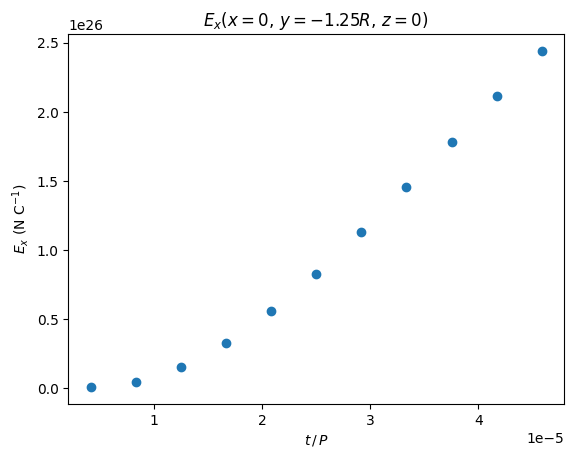

In [288]:
plot_field("E_x", "t")

Number of possible slices to plot is 14
id_t = 24, id_y = 11, id_z = 8


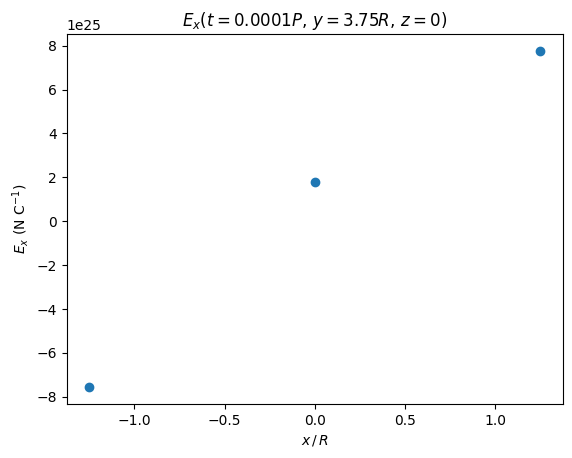

In [289]:
plot_field("E_x", "x")

Number of possible slices to plot is 4
id_t = 9, id_x = 8, id_z = 8


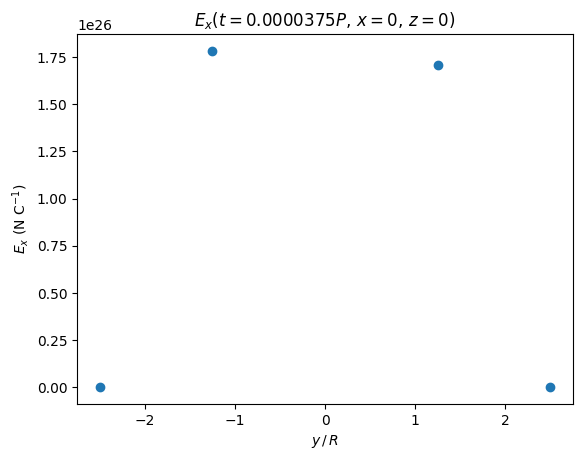

In [290]:
plot_field("E_x", "y")

Number of possible slices to plot is 8
id_t = 26, id_x = 8, id_y = 11


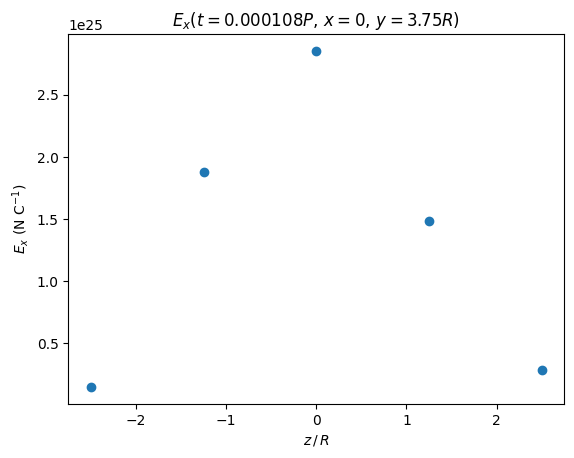

In [291]:
plot_field("E_x", "z")

Number of possible slices to plot is 2
id_x = 9, id_y = 8, id_z = 8


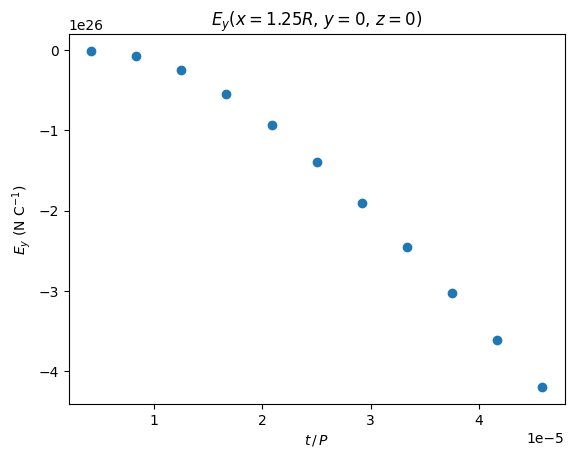

In [292]:
plot_field("E_y", "t")

Number of possible slices to plot is 4
id_t = 18, id_y = 8, id_z = 8


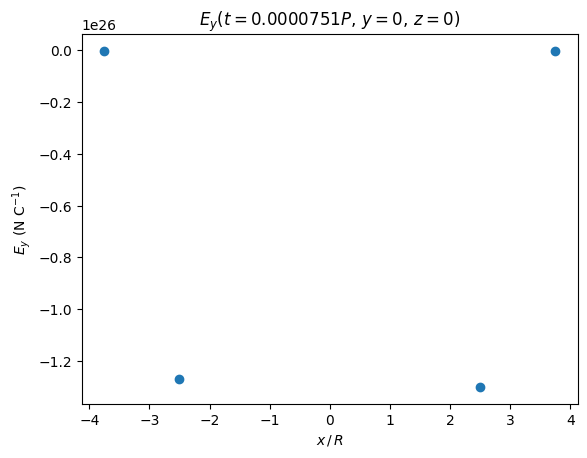

In [293]:
plot_field("E_y", "x")

Number of possible slices to plot is 14
id_t = 24, id_x = 5, id_z = 8


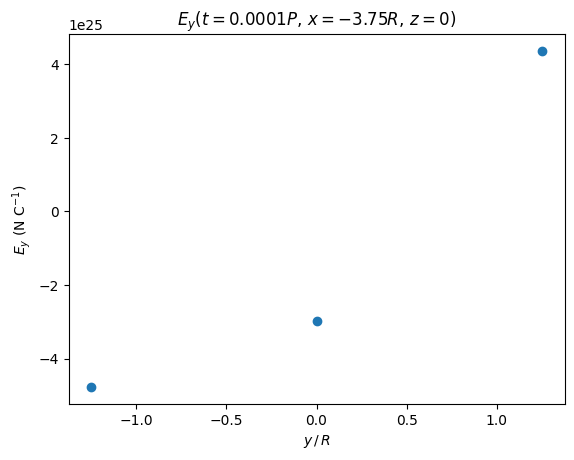

In [294]:
plot_field("E_y", "y")

Number of possible slices to plot is 8
id_t = 26, id_x = 11, id_y = 8


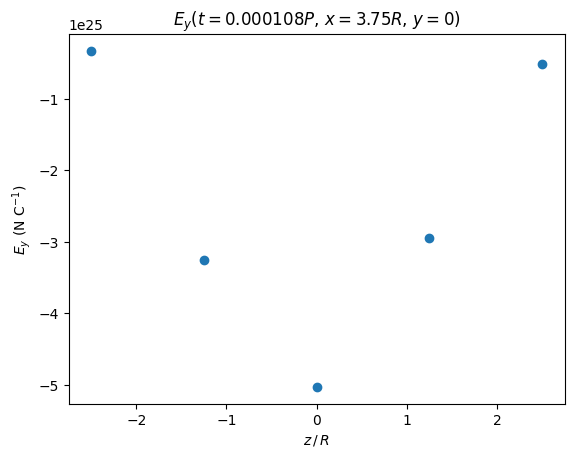

In [295]:
plot_field("E_y", "z")

Number of possible slices to plot is 24
id_x = 11, id_y = 8, id_z = 8


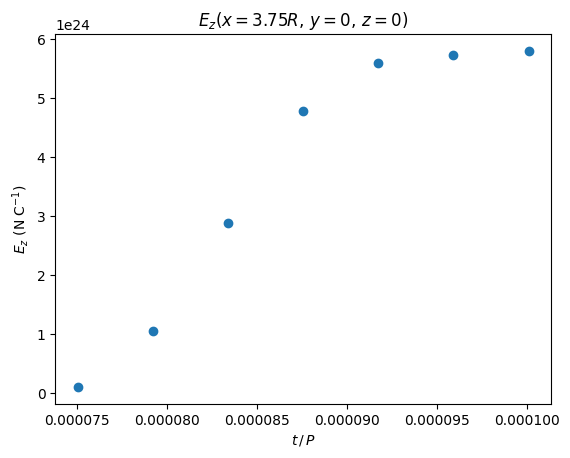

In [296]:
plot_field("E_z", "t")

Number of possible slices to plot is 2
id_t = 24, id_y = 11, id_z = 8


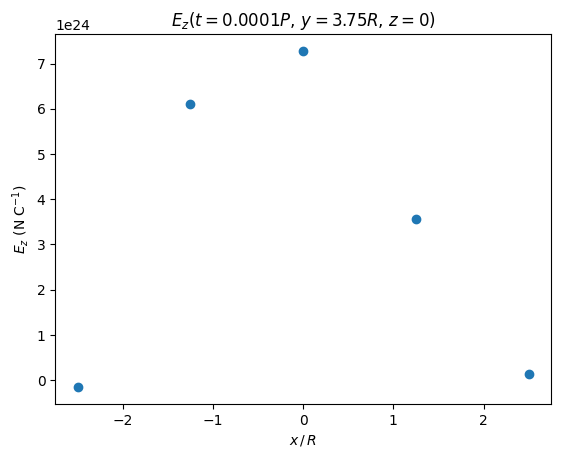

In [297]:
plot_field("E_z", "x")

Number of possible slices to plot is 2
id_t = 24, id_x = 5, id_z = 8


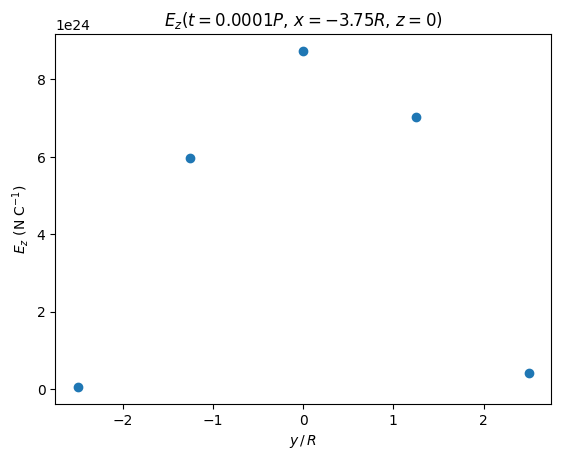

In [298]:
plot_field("E_z", "y")

Number of possible slices to plot is 68
id_t = 29, id_x = 5, id_y = 10


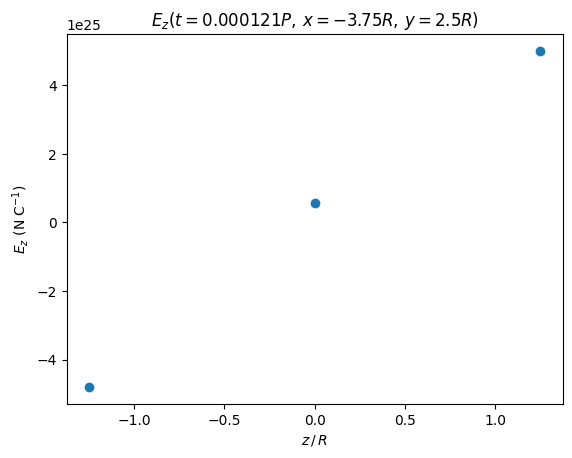

In [299]:
plot_field("E_z", "z")

Number of possible slices to plot is 2
id_x = 7, id_y = 8, id_z = 8


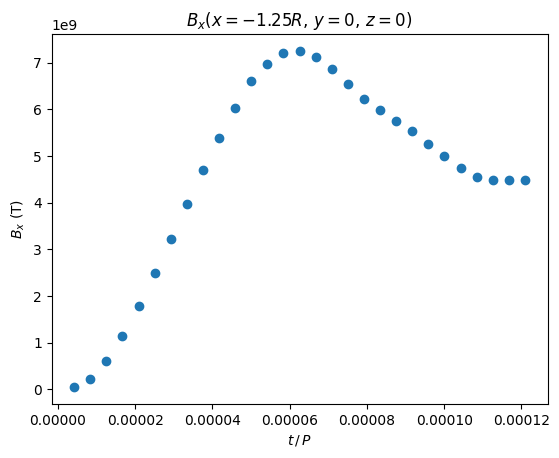

In [300]:
plot_field("B_x", "t")

Number of possible slices to plot is 2
id_t = 29, id_y = 8, id_z = 8


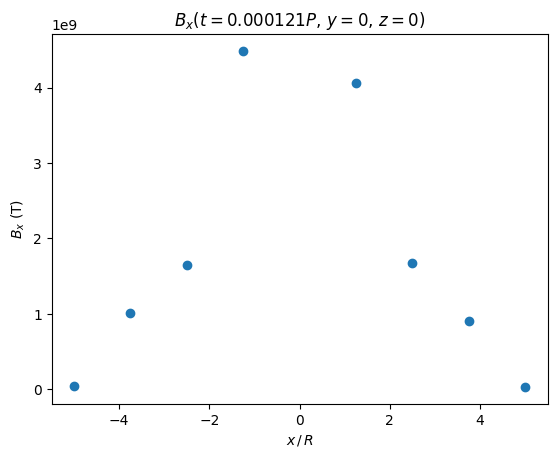

In [301]:
plot_field("B_x", "x")

Number of possible slices to plot is 8
id_t = 29, id_x = 9, id_z = 8


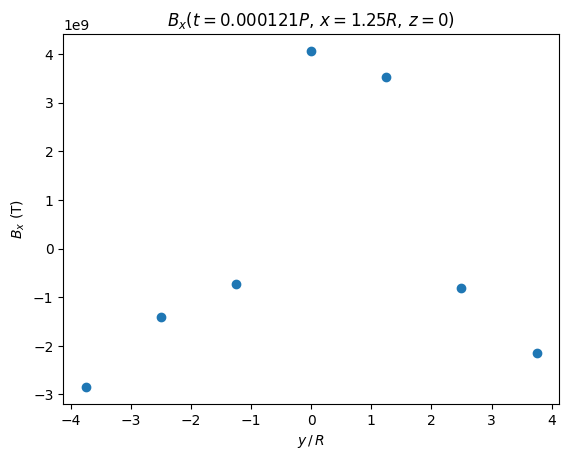

In [302]:
plot_field("B_x", "y")

Number of possible slices to plot is 8
id_t = 29, id_x = 9, id_y = 9


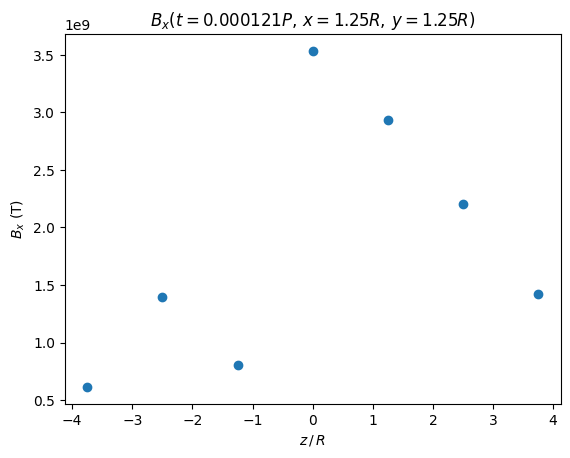

In [303]:
plot_field("B_x", "z")

Number of possible slices to plot is 2
id_x = 8, id_y = 7, id_z = 8


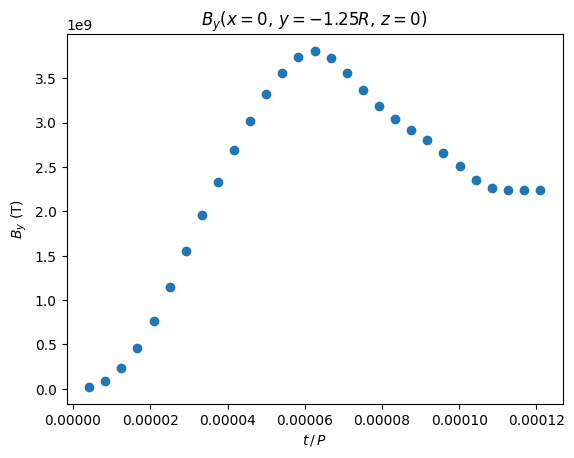

In [304]:
plot_field("B_y", "t")

Number of possible slices to plot is 8
id_t = 29, id_y = 9, id_z = 7


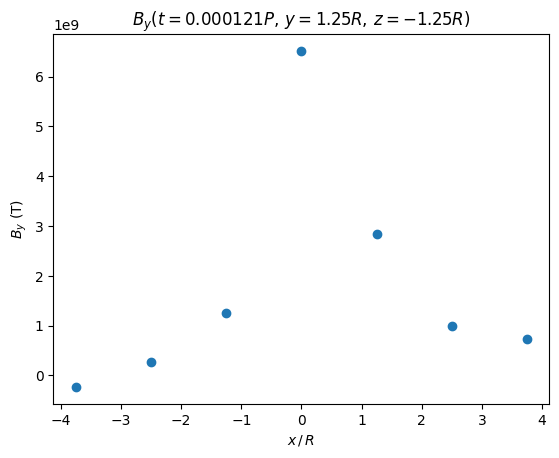

In [305]:
plot_field("B_y", "x")

Number of possible slices to plot is 2
id_t = 29, id_x = 8, id_z = 8


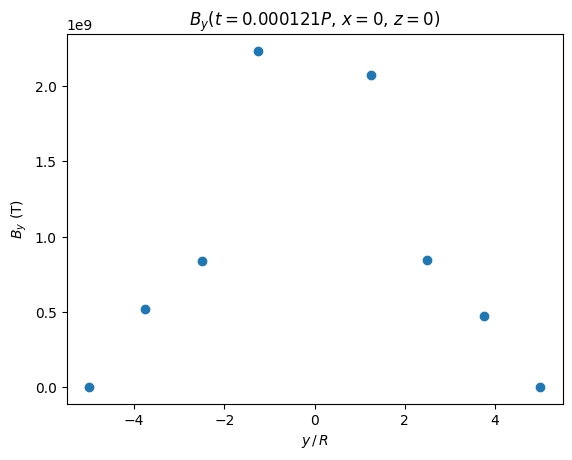

In [306]:
plot_field("B_y", "y")

Number of possible slices to plot is 8
id_t = 28, id_x = 8, id_y = 7


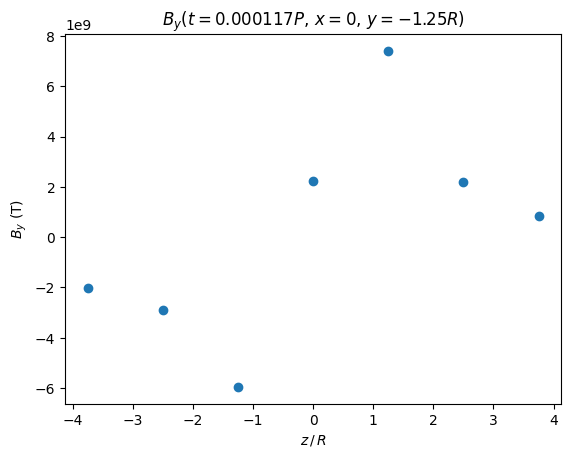

In [307]:
plot_field("B_y", "z")

Number of possible slices to plot is 2
id_x = 8, id_y = 8, id_z = 9


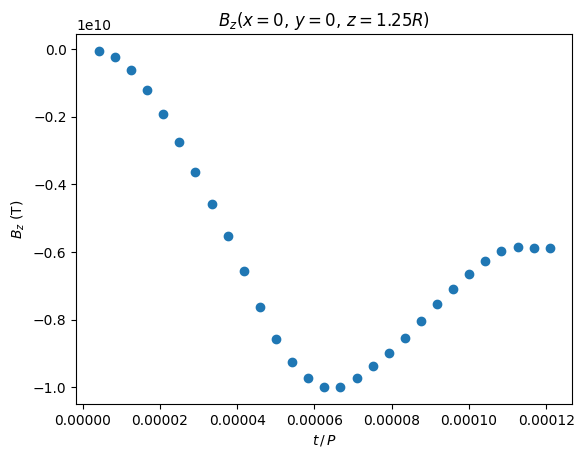

In [308]:
plot_field("B_z", "t")

Number of possible slices to plot is 8
id_t = 29, id_y = 7, id_z = 9


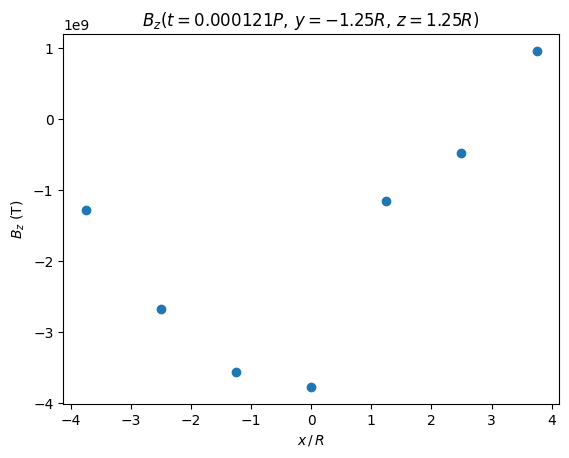

In [309]:
plot_field("B_z", "x")

Number of possible slices to plot is 8
id_t = 29, id_x = 9, id_z = 7


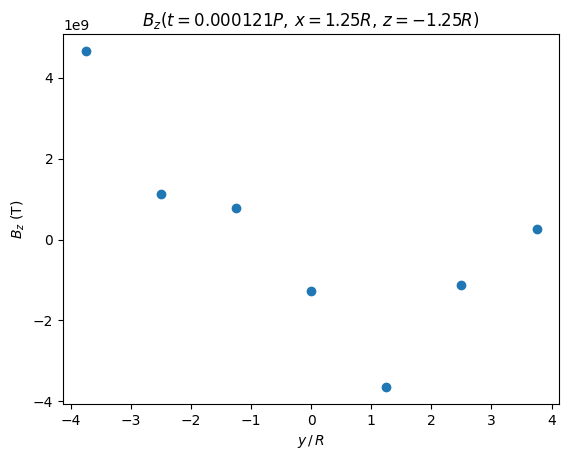

In [310]:
plot_field("B_z", "y")

Number of possible slices to plot is 2
id_t = 29, id_x = 8, id_y = 8


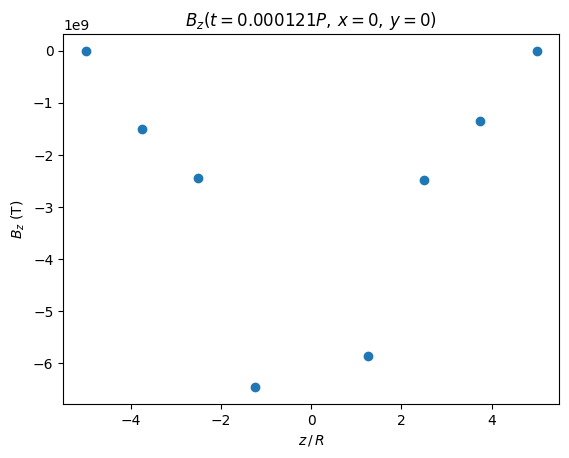

In [311]:
plot_field("B_z", "z")